Learned theta (scaled):
θ₀ bias:2.0031  (true scaled: 2.0000)
θ₁ experience:3.0197  (true scaled: 0.3000)
θ₂ education:4.9985  (true scaled: 0.5000)


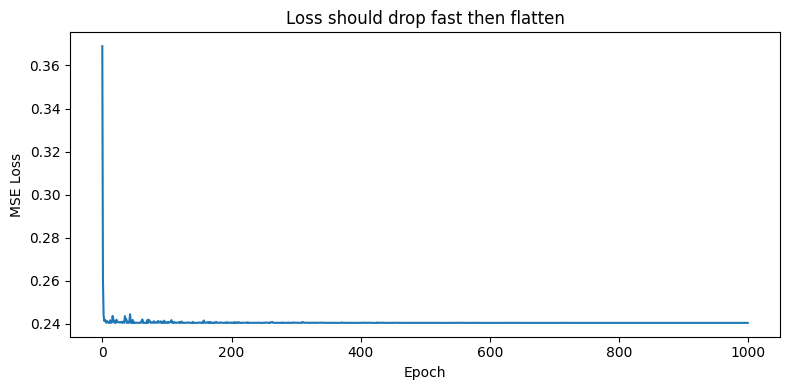


Predicted salary (8yr exp, 10yr edu): $94.2k
Expected from true formula: $94.0k


In [7]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)
m = 2000

experiences = rng.exponential(scale=4, size=(m, 1))
education = rng.normal(7, 4, size=(m, 1))

TRUE_BIAS = 20.0
TRUE_W_EXP = 3.0
TRUE_W_EDU = 5.0

salaries = (TRUE_BIAS + 
            TRUE_W_EXP * experiences + 
            TRUE_W_EDU * education + 
            rng.normal(0, 5, size=(m, 1)))

from sklearn.preprocessing import add_dummy_feature

X = np.hstack([experiences / 10, education / 10])
X_dummy = add_dummy_feature(X)
y = salaries / 10


n_epochs = 1000
minibatch_size = 20
n_batches_per_epoch = np.ceil(m / minibatch_size).astype('int')
t0, t1 = 500, 5000

# eta = 0.1

def learning_schedule(t):
    return t0 / (t + t1)

theta = rng.standard_normal((3, 1))

loss_history = []

for epoch in range(n_epochs):
    shuffled_indices = rng.permutation(m)
    X_dummy_shuffled = X_dummy[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(n_batches_per_epoch):

        idx = iteration * minibatch_size
        xi = X_dummy_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        predictions = xi @ theta
        errors = predictions - yi
        gradients = 1 / len(xi) * xi.T @ errors
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients


    y_pred_full = X_dummy @ theta
    full_errors = y_pred_full - y
    mse = float(np.mean(full_errors ** 2))
    loss_history.append(mse)

print("Learned theta (scaled):")
print(f"θ₀ bias:{theta[0,0]:.4f}  (true scaled: {TRUE_BIAS  /10:.4f})")
print(f"θ₁ experience:{theta[1,0]:.4f}  (true scaled: {TRUE_W_EXP/10:.4f})")
print(f"θ₂ education:{theta[2,0]:.4f}  (true scaled: {TRUE_W_EDU/10:.4f})")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss should drop fast then flatten")
plt.tight_layout()
plt.show()

X_test = add_dummy_feature(np.array([[8/10, 10/10]]))
pred_scaled = X_test @ theta
pred_salary = pred_scaled * 10                        

print(f"\nPredicted salary (8yr exp, 10yr edu): ${pred_salary[0,0]:.1f}k")
print(f"Expected from true formula: ${TRUE_BIAS + TRUE_W_EXP*8 + TRUE_W_EDU*10:.1f}k")